In [128]:
# Minilibro de jupyter 1, aqui se establecera la ruta en donde se trabajaran los archivos para que jupyter no tenga problema alguno

# Para trabajar sin trabas en un Jupyter Notebook es necesario identificar bien la ruta de acceso a todos los archivos, para lo cual se ejecuta el siguiente codigo
# import os
# os.chdir("D:\Documentos\proyecto python UCM vino")

#lo anterior es para solamente trabajar de forma local, ya que como se mencionara posteriormente aqui se estara trabajando con los documentos en la nube.



In [ ]:
#Antes que nada, asumir que tienen python instalado junto con Visual Studio Code para un trabajo mas comodo, tambien instalar ciertas librerias para poder importarlas despues sin mayor problema, estas librerias son: ...pandas, matplot, seaborn, statsmodel, numpy, scipy, patsy, y sckit learn, etc etc etc.

# ANALISIS DE DATOS - PROYECTO DEL VINO.


# Importamos las librerias que se utilizaran para realizar el EDA
import pandas as pd #importa la libreria de pandas con el alias de pd, utilizada para la manipulacion y el analisis de datos en estructuras como los dataframes
import seaborn as sns #Importa la libreria de seaborn, con el alias de sns, utilizada para graficos estadisticos mas avanzados y esteticamente mas agradables como heatmaps, etc
import matplotlib.pyplot as plt #importa la libreria de graficos matplotlib y le asigna el alias de plt para crear despues figuras, graficos, titulos, etc
# No ejecutar estas lineas por si sola, ya que se abre el prompt interactivo de python, en caso de suceder eso escribir "exit()".


# Le decimos a Python que lea el archivo CSV.
# IMPORTANTE: El archivo 'wine_train.csv' debe estar en la misma carpeta que este archivo .py.
# Tambien revisar bien el directorio del la terminal del archive ya que si no, no se ubicara el archivo "wine_train", si hay problemas en la terminal se coloca "cd "ruta"".
# En este caso para mayor facilidad y practicidad, se subio el archivo a github para facilitar su aplicacion, aunque tambien se puede hacer de forma local haciendo lo que dije anteriormente

url_train = "https://raw.githubusercontent.com/MMaxuss/Modelo-Vinos-UCM/refs/heads/main/wine_train.csv"

df = pd.read_csv(url_train) # Aqui la funcion utilizada es el read_csv, esta funcion tambien viene de la libreria pandas y lo que hace es leer un archivo csv y cargarlo como un DataFrame de pandas


# Revisamos la forma del dataset (filas, columnas).

# Aqui la funcion utilizada es el shape, el cual viene de la libreria pandas (del DataFrame); esto devuelve el n de filas y columnas con la forma del DataFrame, sirve para poder ver cuantas filas y columnas tiene el dataset

print("Forma al inicio del dataset (filas, columnas):", df.shape)

#  Como el wine_test adjunto coloca todas las variables en una sola columna, lo separamos de forma automatica para mejor orden.
# Tomamos esa única columna y la separamos donde haya comas 
# (CUIDADO AQUI, YA QUE ESTO REVISA SI ESTA BIEN DESDE UN INICIO O NO, al momento de hacerlo de forma forzosa se puede estropear el codigo).

# La funcion utilizada principalmente es el df.columns, esto viene del paquete de pandas (Dataframe) y sirve para identificar, ya que devuelve todos los nombres de las columnas
# df = df[df.columns[0]]; esto selecciona la primera columna del dataframe
# .str.split(",", expand=True); esto tambien es de la libreria de pandas y en este caso divide cada valor de la serie usando la coma como separador 
# el expand=True genera un dataframe nuevo, con el cual cada valor se crea en una columna por separado	

# las lineas de codigo df.iloc, df[1:] y new_header, sirven para devolver la primera fila completa del dataframe, eliminar el duplicado que se usa como header y asignar estos nombres de 1ra fila para las columnas respectivamente; todas estas funciones pertenecientes a la libreria del pandas

if df.shape[1] == 1:
    df = df[df.columns[0]].str.split(",", expand=True)
    new_header = df.iloc[0]
    df = df[1:]
    df.columns = new_header
    print("Nueva forma del dataset:", df.shape)

    
# Para mayor orden, usamos la primera fila como nombre de las columnas, identificando el id, las variables, etc.
# Mostramos las primeras 5 filas del dataset tambien para ejemplificar el nuevo orden propuesto.

# La funcion df.head sirve para inspeccionar de forma rapida el dataframe, ya que devuelve las primeras 5 columnas; tambien pertenece al paquete de pandas

print("Nueva forma del dataset:", df.shape)

print("\nPrimeras filas del dataset:\n")
print(df.head())

# Mostramos los nombres de las columnas para ver si las variables se ven de forma correcta.
print("\n Columnas:")
print(df.columns.tolist())

# Convertimos todo lo posible a números (aveces algunos algoritmos solo aceptan datos numericos y asi eliminamos errores altiro).

# al inicio el "for col in df.columns" sirve para alternar todos los nombres de las columnas, despues el "df[col] = df[col].astype(float)" (de pandas tambien) lo que hace es convertir todos los valores de la columna a tipo decimal. Y por ultimo el ValueError es un control de errores de python, en el caso de que algo no se pueda convertir a decimal y se ignore en dicho caso.

for col in df.columns:
    try:
        df[col] = df[col].astype(float)
    except ValueError:
        pass  # Ignora las columnas que no sean numéricas

# Ejemplificamos finalmente como quedaria de forma ordenada el "nuevo" dataset para poder trabajar

# La funcion "df.dtypes", de la libreria pandas lo que hace es devolver los tipos de datos de cada columna (float, object, etc); sirve para verificar si los datos estan correctamente modelados

print("\n Nuevo Dataset:")
print(df.dtypes)

# Ahora que ya se tiene el dataframe listo, se puede seguir trabajando con el data "limpio" en los demas cuadros de jupyter


In [130]:
# para revisar el numero de filas, columnas y tipos de datos se introduce el siguiente codigo

print(df.info()) #df.info es de la libreria pandas y muestra un resumen general del dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          133 non-null    float64
 1   Alcohol                     133 non-null    float64
 2   Acido_malico                133 non-null    float64
 3   Cenizas                     133 non-null    float64
 4   Alcalinidad_cenizas         133 non-null    float64
 5   Magnesio                    133 non-null    float64
 6   Fenoles_totales             133 non-null    float64
 7   Flavonoides                 133 non-null    float64
 8   Fenoles_no_flavonoides      133 non-null    float64
 9   Proantocianidinas           133 non-null    float64
 10  Intensidad_color            133 non-null    float64
 11  Tono_color                  133 non-null    float64
 12  OD280_OD315_vinos_diluidos  133 non-null    float64
 13  Prolina                     133 non

In [147]:
# Despues para revisar medidas basicas (como media, cuartiles, desviacion estandar, etc) se utiliza este codigo

print(df.describe()) #df.describe es tambien de la libreria de pandas y genera estadisticas descriptivas de las columnas numericas del dataframe

# Con esto se puede tener un panorama general de todas nuestras variables, las cuales al ya estar ordenadas, se pueden trabajar de forma independiente.

               id     Alcohol  Acido_malico     Cenizas  Alcalinidad_cenizas  \
count  133.000000  133.000000  1.330000e+02  133.000000         1.330000e+02   
mean    88.300752   13.071429 -4.541063e-16    0.000000        -9.616368e-16   
std     54.763263    0.806262  1.000000e+00    1.000000         1.000000e+00   
min      1.000000   11.450000 -1.312229e+00   -3.662767        -2.677168e+00   
25%     41.000000   12.370000 -6.983298e-01   -0.570341        -6.776762e-01   
50%     87.000000   13.080000 -4.510648e-01   -0.024619         6.059767e-02   
75%    138.000000   13.730000  7.170494e-01    0.775774         5.220189e-01   
max    177.000000   14.830000  2.874224e+00    3.140570         2.829125e+00   

           Magnesio  Fenoles_totales  Flavonoides  Fenoles_no_flavonoides  \
count  1.330000e+02       133.000000   133.000000            1.330000e+02   
mean  -4.006820e-16         0.000000     0.000000           -8.013640e-17   
std    1.000000e+00         1.000000     1.00000

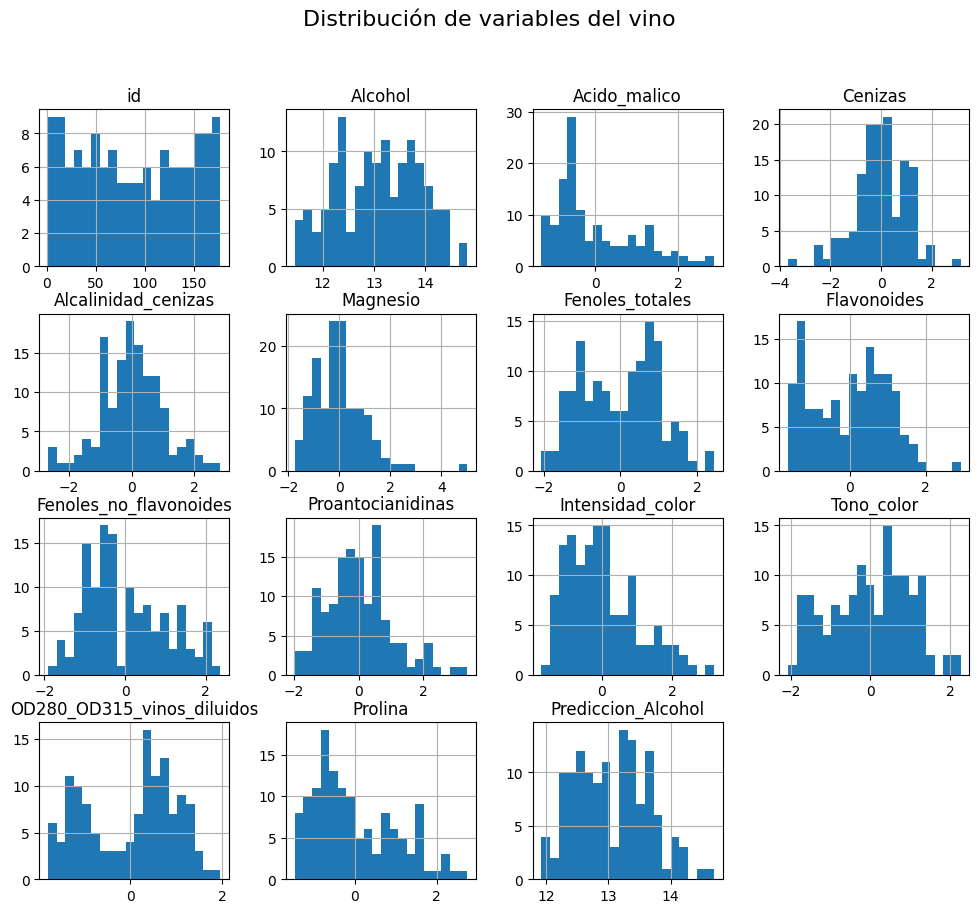

In [132]:

# Histograma general del dataframe
# Para relizarlo se utilizo la libreria de pandas en la funcion df.hist; internamente se utiliza la libreria de matplotlib para graficar
df.hist(bins=20, figsize=(12, 10))
plt.suptitle("Distribución de variables del vino", fontsize=16)
plt.show()

                                  id   Alcohol  Acido_malico   Cenizas  \
id                          1.000000 -0.348585      0.533703  0.006150   
Alcohol                    -0.348585  1.000000      0.045092  0.210704   
Acido_malico                0.533703  0.045092      1.000000  0.161258   
Cenizas                     0.006150  0.210704      0.161258  1.000000   
Alcalinidad_cenizas         0.620296 -0.292171      0.411679  0.438614   
Magnesio                   -0.182862  0.196240     -0.105456  0.291196   
Fenoles_totales            -0.671748  0.298415     -0.378594  0.123863   
Flavonoides                -0.773813  0.230980     -0.462958  0.111936   
Fenoles_no_flavonoides      0.515488 -0.109879      0.364666  0.215881   
Proantocianidinas          -0.381413  0.151734     -0.232896 -0.009707   
Intensidad_color            0.300951  0.501911      0.225756  0.276587   
Tono_color                 -0.722388  0.025929     -0.547656 -0.065079   
OD280_OD315_vinos_diluidos -0.698707  

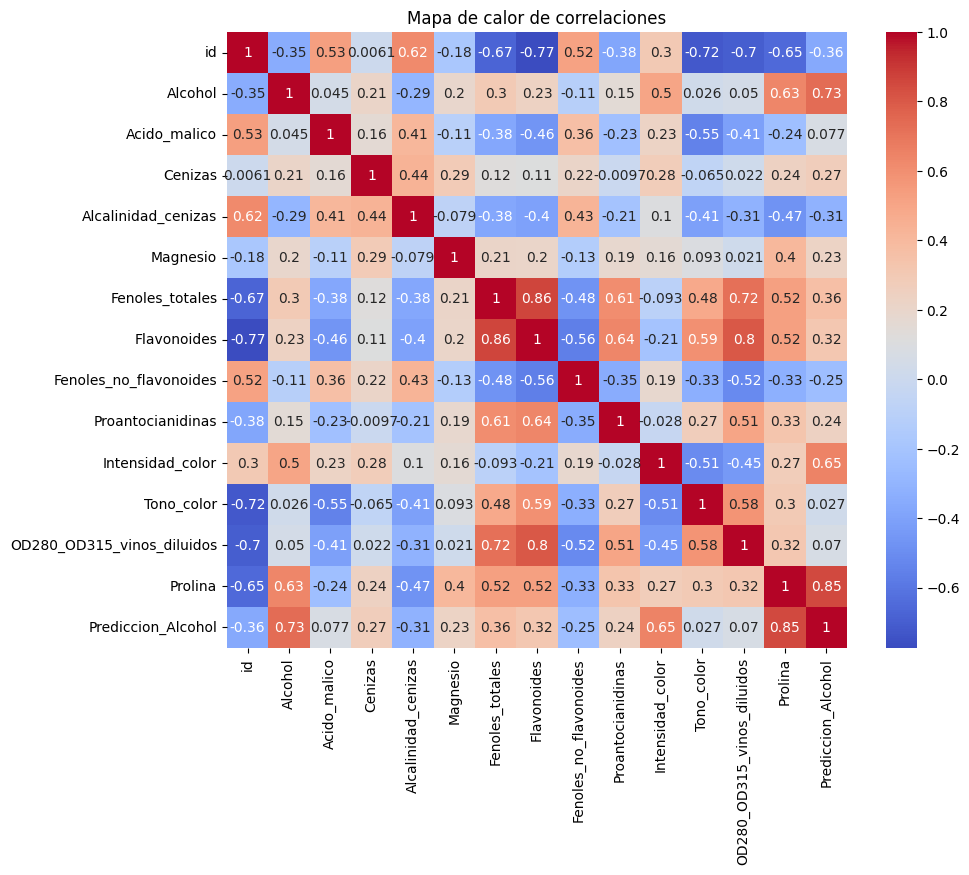

In [133]:
# para visualizar las correlaciones entre todas las variables y sobretodo la respuesta del alcohol, se utiliza la funcion "df.corr" (de que libreria, etc)

correlaciones = df.corr(numeric_only=True) #Esta funcion tambien proviene de pandas y calcula la matriz de correlaciones entre todas las columnas
print(correlaciones)

# Con una imagen, las correlaciones estan mucho mejor explicadas, para esto se tiene que utilizar las librerias de seaborn, con las cuales se ilustraran las correlaciones, cuales son mas fuertes y mas debiles, utilizando un mapa de calor (heatmap).

plt.figure(figsize=(10, 8)) # esta funcion viene de la libreria de matplotlib y crea una nueva figura para poder graficar
sns.heatmap(correlaciones, annot=True, cmap="coolwarm") #esta funcion viene de la libreria de seaborn y genera un mapa de calor de la matriz de las correlaciones
plt.title("Mapa de calor de correlaciones")
plt.show()
#las siguientes funciones solamente ayudan a ver de mejor forma el grafico

In [134]:
# si queremos observar de mejor forma solo las correlaciones de las variables con el alcohol y no entre ellas, se detalla un poco mas la funcion. En este caso tambien se asigno el orden de forma decreciente para mayor claridad.


correlaciones_alcohol = df.corr(numeric_only=True)['Alcohol'].sort_values(ascending=False) # la funcion completa viene de la libreria de pandas y calcula la matriz de todas las columnas con solo la de la columna alcohol, para despues ordenar los valores de forma descendente
print(correlaciones_alcohol)


Alcohol                       1.000000
Prediccion_Alcohol            0.734706
Prolina                       0.633510
Intensidad_color              0.501911
Fenoles_totales               0.298415
Flavonoides                   0.230980
Cenizas                       0.210704
Magnesio                      0.196240
Proantocianidinas             0.151734
OD280_OD315_vinos_diluidos    0.049584
Acido_malico                  0.045092
Tono_color                    0.025929
Fenoles_no_flavonoides       -0.109879
Alcalinidad_cenizas          -0.292171
id                           -0.348585
Name: Alcohol, dtype: float64


In [ ]:
# Con el EDA inicial listo, y visto ya cual de las variables es la que tiene un mayor impacto en nuestra variable respuesta (alcohol) podemos pasar a ver y armar nuestro modelo tecnico para predecir los datos
# Para proceder con esto primero que nada importaremos desde un inicio todas las librerias utilizadas para ir de forma ordenada

import numpy as np #importa numpy con alias np usado para operaciones numericas avanzadas
import statsmodels.api as sm #importa statsmodel con alias sm, utilizado para ajustar modelos estadisticos , regresion lineal (OLS) y obtener metricas como AIC, BIC, R2, etc
from sklearn.model_selection import train_test_split #Importa la funcion para dividir los datasets en conjuntos de entrenamiento y prueba
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #Importa las metricas de desempeño para evaluar los modelos: RMSE, MAE, R2
import scipy.stats as stats #libreria que se especializa en estadistica y probabilidad


# Cabe mencionar de forma express la utilidad tanto de las metricas de desempeño como de los criterios de seleccion
# En resumidas cuentas, las metricas de desempeño (RMSE, MAE y R2), indican o miden el ajuste general de las pruebas, es decir, que tan bien predice el modelo.
# Los criterios de seleccion, cada uno mide e interpreta algo distinto, aunque son muy similares
# AIC y BIC indican parsimonia a nivel mas global, penalizando los modelos con muchas variables; en este sentido, entre menor sea el valor, mejor.
# Cp de Mallows, indica cuanto se aleja un modelo del ideal a considerar, si el cp es cercano o similar al numero de variables se considera bueno, de lo contrario, el modelo puede estar subajustado (faltan variables) o sobreajustado (sobran variables)
# Por ultimo el PRESS, indica errores en las predicciones, del tipo "validacion cruzada", esto ayuda ya que si el PRESS es bajo, significa que el modelo tiene gran capacidad predictiva.

In [ ]:
# Ahora para poder trabajar en los criterios de seleccion mas especificos (cp mallows y PRESS) necesitamos dejar listo las funciones para despues utilizarlas tanto en los criterios de seleccion forward, backward, stepwise y el modelo completo.


# --- Cp de Mallows ---
def mallows_cp(model, model_full, n):
    
    # Con todo esto vamos a poder calcular el Cp de Mallows para un modelo parcial en comparación con el modelo completo.
    # Aqui el "model" va a ser el modelo parcial ajustado y el "model_full" vava ser el modelo completo ajustado
    # "n" es el número de observaciones
    
    SSE_p = np.sum(model.resid ** 2) #np.sum es de numpy y suma todos los elementos de una serie
    MSE_full = np.sum(model_full.resid ** 2) / (n - model_full.df_model - 1) #la funcion model.resid es de statsmodel y devuelde los residuos del modelo ajustado
    p = model.df_model + 1  # incluye el intercepto
    Cp = SSE_p / MSE_full - (n - 2 * p)
    return Cp


# --- PRESS ---
def press_stat(model):
    
    # Esto calculara el PRESS para los modelos de OLS
    influence = model.get_influence() #el model.get_influence viene de statsmodel, lo que hace es devolver un objeto con informacion sobre la influencia de cada observacion en el modelo de regresion
    residuals = influence.resid_studentized_internal  #la funcion viene de statsmodel y obtiene los residuos studentizados internos
    hat_values = influence.hat_matrix_diag #la funcion tambien es de statsmodel y obtiene los valores de la diagonal de la matriz hat de cada observacion
    press = np.sum(((residuals) / (1 - hat_values)) ** 2)
    return press

In [ ]:
# Despues para pasar a trabajar, tenemos que ir eliminando las columnas que no vayamos a utiliar o a manipular en nuestro modelo, en este caso por ejemplo ID y la variable de alcohol no pueden ir en nuestras variables predictoras.
X = df.drop(["id", "Alcohol"], axis=1, errors="ignore")  # eliminamos aqui las variables id y alcohol y tenemos nuestros predictores
y = df["Alcohol"]                                        # el alcohol lo vamos dejando como nuestra variable respuesta

# Despues de todo esto, tenemos que convertir nuestras variables a dummies, (valores de 1 y 0), para poder que no hayan errores al hacer los modelos estadisticos
X = pd.get_dummies(X, drop_first=True) #la funcion es de pandas y convierte variables categoricas en variables dummies

# Despues se añade una constante para statsmodels (intercepto)
# La finalidad principal de esto es poder ajustar bien los modelos de progresion, ya que estos por naturaleza tienen un intercepto de valor "y" para cuando los "x" son 0
# Lo anterior es necesario, ya que de no tener esta constante, el modelo va a forzar a la recta al pasar por el 0, lo cual en la practica real de la vida no tiene sentido, para eso se añade el intercepto.

X_sm = sm.add_constant(X)

# Dividimos train/test para evaluación
# El dividir el train/test significa que se va a tomar cierto % de los datos y se ocupara para aprender los coeficientes del modelo de progresion (el train), y despues esto se usara para evaluar que tan bien el modelo predice los datos que no "vio" (test) durante el entrenamiento.
# Esto es mas que nada para evitar una evaluacion engañosa, si el modelo conociera todo, todo seria perfecto y no sabriamos como se ajustaria a situaciones con valores que se desconoce. 
# En resumen el train enseña el modelo, y el test verifica que tan bien predice el modelo los datos.
# En este caso el modelo train sera del 80% de los datos y el test seran los 20% restantes.

X_train, X_test, y_train, y_test = train_test_split(X_sm, y, test_size=0.2, random_state=42)

In [135]:

#  MODELO COMPLETO DE VARIABLES

# Ahora se establecerá el primer modelo, el cual como modelo control va a poseer todas las variables predictoras.
full_vars = X_sm.columns.tolist() #las funciones son de pandas y devuelven un Index con los nombres de todas las columnas del dataframe

# Se ajusta el modelo completo al train ya antes mencionado
model_full = sm.OLS(y_train, X_train[full_vars]).fit() #las funciones son de statsmodel y crean un modelo de regresion ordinaria (OLS), ademas devuelven un objeto con los coeficientes y metricas

# Aqui se ajusta la prediccion
y_pred_full = model_full.predict(X_test[full_vars]) #la funcion es de statsmodel y genera las predicciones del modelo (OLS)

# Aqui establecemos las metricas de desempeño RMSE, MAE, R2
rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full)) # el mean_swuared_error, proviene de la libreria de scikit learn y calcula el error cuadratico medio MSE entre los valores; despues se utiliza np de la libreria de numpy para calcular la raiz cuadrada del MSE (RMSE)
mae_full = mean_absolute_error(y_test, y_pred_full) #De la libreria de scikit learn tambien, calcula el error absoluto medio (MAE)
r2_full = r2_score(y_test, y_pred_full) #De la libreria de scikit learn calculan el coeficiente de determinacion R2, que mide que proporcion de la variabilidad y es explicada por el modelo


# Despues nos encargamos de agregar los criterios de parsimonia mas especificos como el Cp de mallows y el PRESS

Cp_full = mallows_cp(model_full, model_full, len(y_train))  # comparado consigo mismo, los modelos ajustados y completos
PRESS_full = press_stat(model_full)

# Exportar resultados

print("Modelo completo (Control):")
print(model_full.summary()) # Con esto vamos a poder obtener los criterios de seleccion mas sencillos (AIC y BIC)
print(f"RMSE: {rmse_full:.3f}, MAE: {mae_full:.3f}, R²: {r2_full:.3f}")
print(f"Cp: {Cp_full:.3f}, PRESS: {PRESS_full:.3f}")


#El dataframe para poder despues comparar las variables
df_full = pd.DataFrame({
    "Modelo": ["Completo"],
    "Variables": [len([v for v in full_vars if v != "const"])],
    "RMSE": [rmse_full],
    "MAE": [mae_full],
    "R²": [r2_full],
    "AIC": [model_full.aic],
    "BIC": [model_full.bic],
    "Cp": [Cp_full],
    "PRESS": [PRESS_full]
})

Modelo completo (Control):
                            OLS Regression Results                            
Dep. Variable:                Alcohol   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     9.760
Date:                Sat, 25 Oct 2025   Prob (F-statistic):           5.02e-12
Time:                        00:18:53   Log-Likelihood:                -82.268
No. Observations:                 106   AIC:                             190.5
Df Residuals:                      93   BIC:                             225.2
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [ ]:
# --- MODELO COMPLETO (para comparar el Cp) --- PARA LOS FOWARD BACKWARD Y STEPWISE
model_full = sm.OLS(y_train, X_train).fit()

In [ ]:
# AHORA EMPEZAMOS A CREAR LOS DISTINTOS MODELOS CON LOS CRITERIOS DE SELECCION FOWARD, BACKWARD Y STEPWISE ENFATIZANDO EN LOS RESULTADOS DEL AIC Y BIC

In [ ]:
#FORWARD CON AIC

def forward_selection(X, y, verbose=True):
    remaining = set(X.columns) - {"const"}  # Variables aún no seleccionadas
    selected = ["const"]                    # Comenzamos con solo intercepto
    current_score = float("inf")            # Inicializamos aic muy alto

    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            model = sm.OLS(y, X[selected + [candidate]]).fit() #aqui recien se utilizan dos funciones de statsmodel, sm.OLS y .fit(), las cuales ajustan el modelo de regresion lineal y el otro entrena el modelo con los datos porporcionados
            
            # Calcular Cp y PRESS para este modelo
            Cp = mallows_cp(model, model_full, len(y))
            PRESS = press_stat(model)
            
            scores_with_candidates.append((model.aic, candidate, Cp, PRESS))
        
        # Ordenar por AIC (menor = mejor)
        scores_with_candidates.sort(key=lambda x: x[0])
        best_new_score, best_candidate, best_Cp, best_PRESS = scores_with_candidates[0]
        
        # Si mejora el AIC, agregamos la variable
        if best_new_score < current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
            
            if verbose:
                print(f"Agregando {best_candidate} → AIC: {current_score:.2f}, Cp: {best_Cp:.2f}, PRESS: {best_PRESS:.2f}")
        else:
            break

    return selected

# --- APLICAMOS LA FUNCIÓN ---
forward_vars = forward_selection(X_train, y_train)

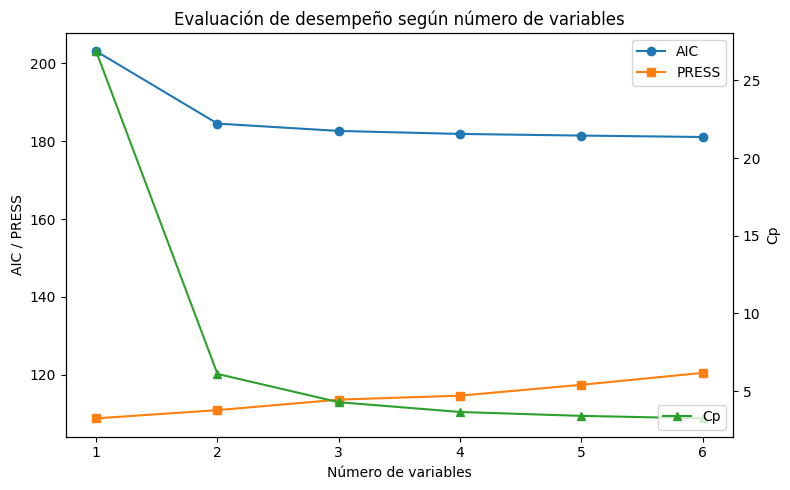

Métricas del modelo final (Stepwise AIC):
   Variables      RMSE       MAE        R²         AIC         BIC        Cp  \
0          4  0.544294  0.429342  0.525719  181.862648  195.179844  3.655101   

        PRESS  
0  114.623677  


In [136]:
#Se puede ver de forma clara como aun cuando el modelo automatizado siguio agregando variables la mejor combinacion estaba en 4, con la prolina, la intensidad de color, el acido malico y el magnesio
#Es la mejor combinacion, ya que las diferencias despues del AIC son marginales, el cp se mantiene bajo y sin embargo, despues de la variable 4 el PRESS comienza a subir, indicando el limite

#Segun los valores arrojados por el modelo foward con prioridad en AIC, se armo un grafico en el cual se puede ver claramente el punto maximo de variables optimo para elegir.
num_vars = [1, 2, 3, 4, 5, 6]
AIC = [203.12, 184.52, 182.63, 181.86, 181.44, 181.07]
PRESS = [108.78, 110.90, 113.59, 114.62, 117.41, 120.47]
Cp = [26.88, 6.11, 4.29, 3.66, 3.41, 3.25]

fig, ax1 = plt.subplots(figsize=(8,5)) #aqui la funcion utilizada es de la libreria de matplot y crea una figura y un eje grafico donde se dibujaran las curvas de este mismo

ax1.plot(num_vars, AIC, marker='o', label='AIC', color='tab:blue') #matplot; dibuja una linea en el eje ax1, donde se grafican AIC Y PRESS
ax1.plot(num_vars, PRESS, marker='s', label='PRESS', color='tab:orange')
ax1.set_xlabel('Número de variables') #Etiquetan eje x y despues el y
ax1.set_ylabel('AIC / PRESS')
ax1.legend(loc='upper right') # agrega una leyenda para poder saber que representa cada linea del grafico

ax2 = ax1.twinx()
ax2.plot(num_vars, Cp, marker='^', label='Cp', color='tab:green') #dibuja la linea de estadistico Cp en el eje derecho
ax2.set_ylabel('Cp') 
ax2.legend(loc='lower right')

plt.title('Evaluación de desempeño según número de variables')
plt.tight_layout()
plt.show()


# Ahora una vez con los datos, ingresamos las variables manualmente para lograr ir calculando las metricas y despues comparar los modelos; esto se realizara con todos los modelos

selected_vars = ["Prolina", "Intensidad_color", "Acido_malico", "Magnesio"]

# Ajustamos modelo solo con esas variables
X_model = X_train[selected_vars] #la funcion x_train es de pandas y selecciona solo una de las columnas
X_model = sm.add_constant(X_model)  # Agrega intercepto
model_final = sm.OLS(y_train, X_model).fit() # la funcion es de statsmodel y ajusta el modelo de regresion lineal con las variables seleccionadas y los datos del entrenamiento

# Predicciones
y_pred = model_final.fittedvalues #la funcion tambien es de statsmodel y devuelve los valores predichos por el modelo en el conjunto de entrenamiento

# Métricas de desempeño
rmse = np.sqrt(mean_squared_error(y_train, y_pred)) #la funcion es de numpy  y calcula el MSE
mae = mean_absolute_error(y_train, y_pred) #La funcion es de sklearn metrics y calcula el MAE
r2 = model_final.rsquared #la funcion es de statsmodel y devuelve el r2
aic = model_final.aic #la funcion es de statsmodel y devuelve el criterio de AIC
bic = model_final.bic #la funcion es de statsmodel y devuelve el criterio BIC
cp = mallows_cp(model_final, model_full, len(y_train))
press = press_stat(model_final)

# Guardamos en un dataframe
df_forward_aic = pd.DataFrame({
    "Variables": [len(selected_vars)],
    "RMSE": [rmse],
    "MAE": [mae],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
    "Cp": [cp],
    "PRESS": [press]
})

print("Métricas del modelo final (Stepwise AIC):")
print(df_forward_aic)


In [ ]:
#Ahora para ir comparando despues los resultados de los distintos modelos (y graficarlos) se iran guardando en distintos dataframes de forma independiente, de forma que, el proceso de crear el modelo, elegir las variables, guardar el dataframe, y guardarlo con los calculos se ira realizando con cada uno de los modelos elegidos para seleccionar las variables

In [ ]:
# --- FORWARD AIC --- PARA COMPARAR
vars_forward_aic = ["Prolina", "Intensidad_color", "Acido_malico", "Magnesio"]
X_forward_aic = sm.add_constant(X_train[vars_forward_aic])
model_forward_aic = sm.OLS(y_train, X_forward_aic).fit()
y_pred_forward_aic = model_forward_aic.fittedvalues
df_forward_aic = pd.DataFrame({
    "Modelo": ["Forward AIC"],
    "Variables": [len(vars_forward_aic)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_pred_forward_aic))],
    "MAE": [mean_absolute_error(y_train, y_pred_forward_aic)],
    "R²": [model_forward_aic.rsquared],
    "AIC": [model_forward_aic.aic],
    "BIC": [model_forward_aic.bic],
    "Cp": [mallows_cp(model_forward_aic, model_full, len(y_train))],
    "PRESS": [press_stat(model_forward_aic)]
})

In [ ]:
#BACKWARD AIC - LAS FUNCIONES UTILIZADAS SON LAS MISMAS QUE CON EL FORWARD

def backward_selection_aic(X, y, verbose=True): 
    selected = list(X.columns)  # Comenzamos con todas las variables
    current_score = sm.OLS(y, X[selected]).fit().aic  # AIC inicial

    while len(selected) > 1:  # Siempre dejamos al menos el intercepto
        scores_with_candidates = []
        for candidate in selected:
            if candidate == "const":  # Nunca eliminamos el intercepto
                continue
            temp_vars = [v for v in selected if v != candidate]
            model = sm.OLS(y, X[temp_vars]).fit()
            
            # Cp y PRESS
            Cp = mallows_cp(model, model_full, len(y))
            PRESS = press_stat(model)
            
            # Usamos AIC para comparar
            scores_with_candidates.append((model.aic, candidate, Cp, PRESS))
        
        # Ordenamos por AIC
        scores_with_candidates.sort(key=lambda x: x[0])
        best_new_score, worst_candidate, best_Cp, best_PRESS = scores_with_candidates[0]
        
        if best_new_score < current_score:
            selected.remove(worst_candidate)
            current_score = best_new_score
            if verbose:
                print(f"Eliminando {worst_candidate} → AIC: {current_score:.2f}, Cp: {best_Cp:.2f}, PRESS: {best_PRESS:.2f}")
        else:
            break
    return selected

# Aplicamos backward selection
backward_vars = backward_selection_aic(X_train, y_train)

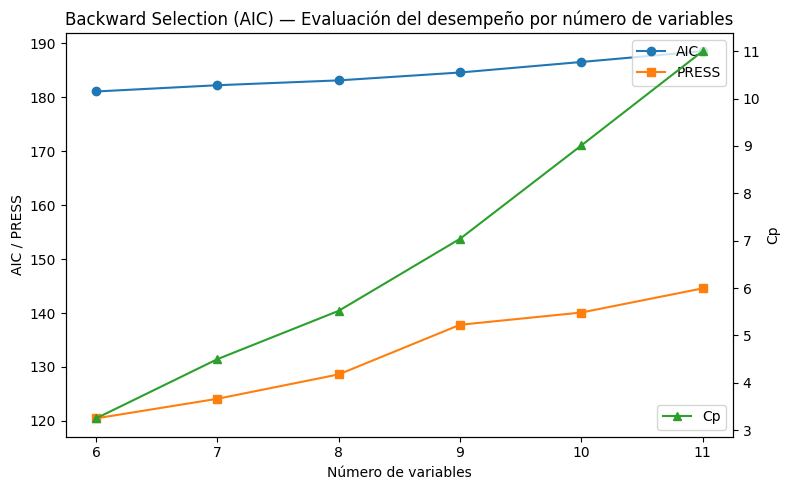

Métricas del modelo final (Backward AIC):
       Criterio  Variables      RMSE       MAE        R²        AIC  \
0  Backward AIC          6  0.532136  0.426972  0.546669  181.07363   

          BIC        Cp       PRESS  
0  199.717704  3.252935  120.467948  


In [137]:
# El modelo backward AIC mostró que a medida que se eliminaban variables, el AIC, Cp y PRESS disminuían hasta cierto punto,
# mostrando una combinación óptima cuando el modelo mantiene pocas variables antes de que el PRESS comience a subir nuevamente.

# Resultados obtenidos en cada paso del backward AIC
num_vars = [11, 10, 9, 8, 7, 6]  # cantidad de variables restantes en cada paso
AIC = [188.54, 186.54, 184.59, 183.13, 182.23, 181.07]
Cp = [11.00, 9.01, 7.04, 5.52, 4.50, 3.25]
PRESS = [144.57, 140.09, 137.82, 128.62, 124.10, 120.47]

# Gráfico de desempeño del modelo Backward AIC
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(num_vars, AIC, marker='o', label='AIC', color='tab:blue')
ax1.plot(num_vars, PRESS, marker='s', label='PRESS', color='tab:orange')
ax1.set_xlabel('Número de variables')
ax1.set_ylabel('AIC / PRESS')
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
ax2.plot(num_vars, Cp, marker='^', label='Cp', color='tab:green')
ax2.set_ylabel('Cp')
ax2.legend(loc='lower right')

plt.title('Backward Selection (AIC) — Evaluación del desempeño por número de variables')
plt.tight_layout()
plt.show()



# Variables finales del modelo Backward AIC (las que realmente se usan, se restan de las que no se usan, esto se sabe por el orden de las)
selected_vars_backward = [
    "Prolina",
    "Intensidad_color",
    "Acido_malico",
    "Magnesio",
    "Tono_color",
    "Fenoles_no_flavonoides"
]

# Ajustamos modelo solo con esas variables
X_model_backward = X_train[selected_vars_backward]
X_model_backward = sm.add_constant(X_model_backward)  # Agregar intercepto
model_backward_final = sm.OLS(y_train, X_model_backward).fit() #ESTE SERA DESPUES EL MODELO PREDILECTO

# Predicciones
y_pred_backward = model_backward_final.fittedvalues

# Métricas de desempeño
rmse_baic = np.sqrt(mean_squared_error(y_train, y_pred_backward))
mae_baic = mean_absolute_error(y_train, y_pred_backward)
r2_baic = model_backward_final.rsquared
aic_baic = model_backward_final.aic
bic_baic = model_backward_final.bic
cp_baic = mallows_cp(model_backward_final, model_full, len(y_train))
press_baic = press_stat(model_backward_final)

# Guardamos en un DataFrame
df_backward_aic = pd.DataFrame({
    "Criterio": ["Backward AIC"],
    "Variables": [len(selected_vars_backward)],
    "RMSE": [rmse_baic],
    "MAE": [mae_baic],
    "R²": [r2_baic],
    "AIC": [aic_baic],
    "BIC": [bic_baic],
    "Cp": [cp_baic],
    "PRESS": [press_baic]
})

print("Métricas del modelo final (Backward AIC):")
print(df_backward_aic)


In [ ]:
# --- BACKWARD AIC --- PARA COMPARAR
vars_backward_aic = ["Prolina", "Intensidad_color", "Acido_malico", "Magnesio", "Tono_color", "Fenoles_no_flavonoides"]
X_backward_aic = sm.add_constant(X_train[vars_backward_aic])
model_backward_aic = sm.OLS(y_train, X_backward_aic).fit()
y_pred_backward_aic = model_backward_aic.fittedvalues
df_backward_aic = pd.DataFrame({
    "Modelo": ["Backward AIC"],
    "Variables": [len(vars_backward_aic)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_pred_backward_aic))],
    "MAE": [mean_absolute_error(y_train, y_pred_backward_aic)],
    "R²": [model_backward_aic.rsquared],
    "AIC": [model_backward_aic.aic],
    "BIC": [model_backward_aic.bic],
    "Cp": [mallows_cp(model_backward_aic, model_full, len(y_train))],
    "PRESS": [press_stat(model_backward_aic)]
})

In [ ]:
#STEPWISE CON AIC

def stepwise_selection(X, y, verbose=True): 
    remaining = set(X.columns) - {"const"}
    selected = ["const"]
    current_score = float("inf")

    while remaining:
        # --- Forward Step --- #AQUI SE APLICAN LOS MISMOS PASOS QUE EN EL FORWARD, es la primera parte 
        scores_with_candidates = []
        for candidate in remaining:
            model = sm.OLS(y, X[selected + [candidate]]).fit()
            Cp = mallows_cp(model, model_full, len(y))
            PRESS = press_stat(model)
            scores_with_candidates.append((model.aic, candidate, Cp, PRESS))
        
        scores_with_candidates.sort(key=lambda x: x[0])
        best_new_score, best_candidate, best_Cp, best_PRESS = scores_with_candidates[0]

        if best_new_score < current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
            if verbose:
                print(f"Agregando {best_candidate} → AIC: {current_score:.2f}, Cp: {best_Cp:.2f}, PRESS: {best_PRESS:.2f}")
            
            # --- Backward Step dentro del stepwise --- #Y AQUI SE APLICAN LOS MISMOS PASOS QUE EN EL BACKWARD, esta es la segunda parte
            while len(selected) > 1:
                scores_with_candidates = []
                for candidate in selected:
                    if candidate == "const":
                        continue
                    temp_vars = [v for v in selected if v != candidate]
                    model = sm.OLS(y, X[temp_vars]).fit()
                    Cp = mallows_cp(model, model_full, len(y))
                    PRESS = press_stat(model)
                    scores_with_candidates.append((model.aic, candidate, Cp, PRESS))
                
                scores_with_candidates.sort(key=lambda x: x[0])
                best_backward_score, worst_candidate, best_Cp, best_PRESS = scores_with_candidates[0]
                
                if best_backward_score < current_score:
                    selected.remove(worst_candidate)
                    current_score = best_backward_score
                    if verbose:
                        print(f"Eliminando {worst_candidate} → AIC: {current_score:.2f}, Cp: {best_Cp:.2f}, PRESS: {best_PRESS:.2f}")
                else:
                    break
        else:
            break
    return selected

# Aplicamos stepwise selection
stepwise_vars = stepwise_selection(X_train, y_train)

In [ ]:
#RECALCAR SIEMPRE QUE LAS FUNCIONES UTILIZADAS SON SIEMPRE LAS MISMAS

In [ ]:
# El modelo Stepwise AIC muestra un comportamiento similar al Forward:
# el algoritmo sigue agregando variables hasta llegar a 6, pero el mejor rendimiento real ocurre con 4 variables.
# Después de la cuarta, el AIC apenas mejora mientras que el PRESS comienza a aumentar.
#Según los valores arrojados por el modelo stepwise con prioridad en AIC, 
#se armó un gráfico en el cual se puede ver claramente el punto máximo de variables óptimo para elegir.

num_vars = [1, 2, 3, 4, 5, 6]
AIC = [203.12, 184.52, 182.63, 181.86, 181.44, 181.07]
PRESS = [108.78, 110.90, 113.59, 114.62, 117.41, 120.47]
Cp = [26.88, 6.11, 4.29, 3.66, 3.41, 3.25]

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(num_vars, AIC, marker='o', label='AIC', color='tab:blue')
ax1.plot(num_vars, PRESS, marker='s', label='PRESS', color='tab:orange')
ax1.set_xlabel('Número de variables')
ax1.set_ylabel('AIC / PRESS')
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
ax2.plot(num_vars, Cp, marker='^', label='Cp', color='tab:green')
ax2.set_ylabel('Cp')
ax2.legend(loc='lower right')

plt.title('Evaluación de desempeño según número de variables — Stepwise AIC')
plt.tight_layout()
plt.show()


#Luego, para visualizar mejor el punto óptimo, se elaboró un dataframe simple 
#con las 4 variables más representativas del modelo seleccionado manualmente.

# Variables seleccionadas manualmente
selected_vars = ["Prolina", "Intensidad_color", "Acido_malico", "Magnesio"]

# Ajustamos modelo solo con esas variables
X_model = X_train[selected_vars]
X_model = sm.add_constant(X_model)  # Agregar intercepto
model_stepwise_final = sm.OLS(y_train, X_model).fit()

# Predicciones
y_pred = model_final.fittedvalues

# Métricas de desempeño
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
mae = mean_absolute_error(y_train, y_pred)
r2 = model_final.rsquared
aic = model_final.aic
bic = model_final.bic
cp = mallows_cp(model_final, model_full, len(y_train))
press = press_stat(model_final)

# Guardamos en un dataframe
df_stepwise_aic = pd.DataFrame({
    "Variables": [len(selected_vars)],
    "RMSE": [rmse],
    "MAE": [mae],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
    "Cp": [cp],
    "PRESS": [press]
})

print("Métricas del modelo final (Stepwise AIC):")
print(df_stepwise_aic)

In [ ]:
# --- STEPWISE AIC --- PARA COMPARAR
vars_stepwise_aic = ["Prolina", "Intensidad_color", "Acido_malico", "Magnesio"]
X_stepwise_aic = sm.add_constant(X_train[vars_stepwise_aic])
model_stepwise_aic = sm.OLS(y_train, X_stepwise_aic).fit()
y_pred_stepwise_aic = model_stepwise_aic.fittedvalues
df_stepwise_aic = pd.DataFrame({
    "Modelo": ["Stepwise AIC"],
    "Variables": [len(vars_stepwise_aic)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_pred_stepwise_aic))],
    "MAE": [mean_absolute_error(y_train, y_pred_stepwise_aic)],
    "R²": [model_stepwise_aic.rsquared],
    "AIC": [model_stepwise_aic.aic],
    "BIC": [model_stepwise_aic.bic],
    "Cp": [mallows_cp(model_stepwise_aic, model_full, len(y_train))],
    "PRESS": [press_stat(model_stepwise_aic)]
})

In [ ]:
#Ahora que ya se vio los criterios de prediccion enfatizando en el AIC, seguiremos con el BIC, la idea de esto es que los modelos vayan cambiando y dejen de agregar o quitar variables cuando el BIC no cambie

In [ ]:
#FORWARD CON BIC

def forward_selection_bic(X, y, verbose=True):
    remaining = set(X.columns) - {"const"}  # Variables aún no seleccionadas
    selected = ["const"]                     # Comenzamos con solo intercepto
    current_score = float("inf")             # Inicializamos BIC muy alto

    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            model = sm.OLS(y, X[selected + [candidate]]).fit()
            
            # Calcular Cp y PRESS para este modelo
            Cp = mallows_cp(model, model_full, len(y))
            PRESS = press_stat(model)
            
            # Usamos BIC como criterio de selección
            scores_with_candidates.append((model.bic, candidate, Cp, PRESS))
        
        # Ordenar por BIC (menor = mejor)
        scores_with_candidates.sort(key=lambda x: x[0])
        best_new_score, best_candidate, best_Cp, best_PRESS = scores_with_candidates[0]
        
        # Si mejora el BIC, agregamos la variable
        if best_new_score < current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
            
            if verbose:
                print(f"Agregando {best_candidate} → BIC: {current_score:.2f}, Cp: {best_Cp:.2f}, PRESS: {best_PRESS:.2f}")
        else:
            break

    return selected

# --- APLICAMOS LA FUNCIÓN ---
forward_vars_bic = forward_selection_bic(X_train, y_train)

In [ ]:
#Con este modelo, al ser mas estricto en cuanto a las variables se puede ver como el criterio de seleccion simplemente incluye 2 variables en el modelo de prediccion, no hay mas que detallar.

# Variables seleccionadas manualmente
selected_vars = ["Prolina", "Intensidad_color"]

# Ajustamos modelo solo con esas variables
X_model = X_train[selected_vars]
X_model = sm.add_constant(X_model)  # Agregar intercepto
model_final = sm.OLS(y_train, X_model).fit()

# Predicciones
y_pred = model_final.fittedvalues

# Métricas de desempeño
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
mae = mean_absolute_error(y_train, y_pred)
r2 = model_final.rsquared
aic = model_final.aic
bic = model_final.bic
cp = mallows_cp(model_final, model_full, len(y_train))
press = press_stat(model_final)

# Guardamos en un dataframe
df_foward_bic = pd.DataFrame({
    "Variables": [len(selected_vars)],
    "RMSE": [rmse],
    "MAE": [mae],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
    "Cp": [cp],
    "PRESS": [press]
})

print("Métricas del modelo final (Forward BIC):")
print(df_foward_bic)

In [ ]:
# --- FORWARD BIC --- PARA COMPARAR
vars_forward_bic = ["Prolina", "Intensidad_color"]
X_forward_bic = sm.add_constant(X_train[vars_forward_bic])
model_forward_bic = sm.OLS(y_train, X_forward_bic).fit()
y_pred_forward_bic = model_forward_bic.fittedvalues
df_forward_bic = pd.DataFrame({
    "Modelo": ["Forward BIC"],
    "Variables": [len(vars_forward_bic)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_pred_forward_bic))],
    "MAE": [mean_absolute_error(y_train, y_pred_forward_bic)],
    "R²": [model_forward_bic.rsquared],
    "AIC": [model_forward_bic.aic],
    "BIC": [model_forward_bic.bic],
    "Cp": [mallows_cp(model_forward_bic, model_full, len(y_train))],
    "PRESS": [press_stat(model_forward_bic)]
})

In [ ]:
#BACKWARD CON BIC

def backward_selection_bic(X, y, verbose=True):
    selected = list(X.columns)  # Comenzamos con todas las variables
    current_score = sm.OLS(y, X[selected]).fit().bic  # BIC inicial

    while len(selected) > 1:  # Siempre dejamos al menos el intercepto
        scores_with_candidates = []
        for candidate in selected:
            if candidate == "const":  # Nunca eliminamos el intercepto
                continue
            temp_vars = [v for v in selected if v != candidate]
            model = sm.OLS(y, X[temp_vars]).fit()
            
            # Cp y PRESS
            Cp = mallows_cp(model, model_full, len(y))
            PRESS = press_stat(model)
            
            # Usamos BIC para comparar
            scores_with_candidates.append((model.bic, candidate, Cp, PRESS))
        
        # Ordenamos por BIC
        scores_with_candidates.sort(key=lambda x: x[0])
        best_new_score, worst_candidate, best_Cp, best_PRESS = scores_with_candidates[0]
        
        if best_new_score < current_score:
            selected.remove(worst_candidate)
            current_score = best_new_score
            if verbose:
                print(f"Eliminando {worst_candidate} → BIC: {current_score:.2f}, Cp: {best_Cp:.2f}, PRESS: {best_PRESS:.2f}")
        else:
            break
    return selected

# Aplicamos backward selection
backward_vars_bic = backward_selection_bic(X_train, y_train)


In [ ]:
#Esto quiere decir varias cosas, principalmente que los modelos mas similares cuentan de 4 variables (la prolina, la intensidad del color, el acido malico y magnesio), y de 3 variables (la prolina y la intensidad de color y acido malico)
#Ahora, aunque el modelo con 3 variables presenta una ligera mejora en BIC y PRESS, el incremento en Cp y la mayor complejidad no justifican su uso.
#Por tanto, el modelo con 4 variables ofrece el mejor equilibrio entre ajuste, simplicidad y capacidad predictiva.

# Datos manuales (según los resultados)
num_vars = [11, 10, 9, 8, 7, 6, 5, 4, 3, 2]
BIC = [220.50, 215.84, 211.22, 207.10, 203.54, 199.72, 197.42, 195.18, 193.29, 192.51]
Cp = [11.00, 9.01, 7.04, 5.52, 4.50, 3.25, 3.41, 3.66, 4.29, 6.11]
PRESS = [144.57, 140.09, 137.82, 128.62, 124.10, 120.47, 117.41, 114.62, 113.59, 110.90]

fig, ax1 = plt.subplots(figsize=(8,5))

# Eje principal (BIC y PRESS)
ax1.plot(num_vars, BIC, marker='o', label='BIC', color='tab:blue')
ax1.plot(num_vars, PRESS, marker='s', label='PRESS', color='tab:orange')
ax1.set_xlabel('Número de variables')
ax1.set_ylabel('BIC / PRESS')
ax1.legend(loc='upper right')

# Segundo eje (Cp)
ax2 = ax1.twinx()
ax2.plot(num_vars, Cp, marker='^', label='Cp', color='tab:green')
ax2.set_ylabel('Cp')
ax2.legend(loc='lower right')

plt.title('Evaluación de desempeño según número de variables (Backward - BIC)')
plt.tight_layout()
plt.show()



# Variables seleccionadas manualmente
selected_vars = ["Prolina", "Intensidad_color", "Acido_malico", "Magnesio"]

# Ajustamos modelo solo con esas variables
X_model = X_train[selected_vars]
X_model = sm.add_constant(X_model)  # Agregar intercepto
model_final = sm.OLS(y_train, X_model).fit()

# Predicciones
y_pred = model_final.fittedvalues

# Métricas de desempeño
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
mae = mean_absolute_error(y_train, y_pred)
r2 = model_final.rsquared
aic = model_final.aic
bic = model_final.bic
cp = mallows_cp(model_final, model_full, len(y_train))
press = press_stat(model_final)

# Guardamos en un dataframe
df_backward_bic = pd.DataFrame({
    "Variables": [len(selected_vars)],
    "RMSE": [rmse],
    "MAE": [mae],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
    "Cp": [cp],
    "PRESS": [press]
})

print("Métricas del modelo final (Backward BIC):")
print(df_backward_bic)

In [ ]:
# --- BACKWARD BIC --- PARA COMPARAR
vars_backward_bic = ["Prolina", "Intensidad_color", "Acido_malico", "Magnesio"]
X_backward_bic = sm.add_constant(X_train[vars_backward_bic])
model_backward_bic = sm.OLS(y_train, X_backward_bic).fit()
y_pred_backward_bic = model_backward_bic.fittedvalues
df_backward_bic = pd.DataFrame({
    "Modelo": ["Backward BIC"],
    "Variables": [len(vars_backward_bic)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_pred_backward_bic))],
    "MAE": [mean_absolute_error(y_train, y_pred_backward_bic)],
    "R²": [model_backward_bic.rsquared],
    "AIC": [model_backward_bic.aic],
    "BIC": [model_backward_bic.bic],
    "Cp": [mallows_cp(model_backward_bic, model_full, len(y_train))],
    "PRESS": [press_stat(model_backward_bic)]
})

In [ ]:
# STEPWISE CON BIC

def stepwise_selection_bic(X, y, verbose=True):  
    remaining = set(X.columns) - {"const"}
    selected = ["const"]
    current_score = float("inf")  # Inicializamos BIC muy alto

    while remaining:
        # --- Paso Forward ---
        scores_with_candidates = []
        for candidate in remaining:
            model = sm.OLS(y, X[selected + [candidate]]).fit()
            Cp = mallows_cp(model, model_full, len(y))
            PRESS = press_stat(model)
            scores_with_candidates.append((model.bic, candidate, Cp, PRESS))  # Cambio aquí: BIC
        
        # Ordenamos por BIC (menor = mejor)
        scores_with_candidates.sort(key=lambda x: x[0])
        best_new_score, best_candidate, best_Cp, best_PRESS = scores_with_candidates[0]

        if best_new_score < current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
            if verbose:
                print(f"Agregando {best_candidate} → BIC: {current_score:.2f}, Cp: {best_Cp:.2f}, PRESS: {best_PRESS:.2f}")
            
            # --- Paso Backward dentro del Stepwise ---
            while len(selected) > 1:
                scores_with_candidates = []
                for candidate in selected:
                    if candidate == "const":
                        continue
                    temp_vars = [v for v in selected if v != candidate]
                    model = sm.OLS(y, X[temp_vars]).fit()
                    Cp = mallows_cp(model, model_full, len(y))
                    PRESS = press_stat(model)
                    scores_with_candidates.append((model.bic, candidate, Cp, PRESS))  # BIC también aquí
                
                scores_with_candidates.sort(key=lambda x: x[0])
                best_backward_score, worst_candidate, best_Cp, best_PRESS = scores_with_candidates[0]
                
                if best_backward_score < current_score:
                    selected.remove(worst_candidate)
                    current_score = best_backward_score
                    if verbose:
                        print(f"Eliminando {worst_candidate} → BIC: {current_score:.2f}, Cp: {best_Cp:.2f}, PRESS: {best_PRESS:.2f}")
                else:
                    break
        else:
            break
    return selected

# Aplicamos stepwise selection
stepwise_vars_bic = stepwise_selection_bic(X_train, y_train)

In [ ]:
#Aqui al igual que con el forward de BIC, solamente se detuvo al agregar dos variables debido al castigo severo que genera este criterio de seleccion, sin embargo, como se puede volver a evidenciar el nivel de cp sigue siendo un poco alto en comparacion al numero de variables
# Variables seleccionadas manualmente
selected_vars = ["Prolina", "Intensidad_color"]

# Ajustamos modelo solo con esas variables
X_model = X_train[selected_vars]
X_model = sm.add_constant(X_model)  # Agregar intercepto
model_final = sm.OLS(y_train, X_model).fit()

# Predicciones
y_pred = model_final.fittedvalues

# Métricas de desempeño
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
mae = mean_absolute_error(y_train, y_pred)
r2 = model_final.rsquared
aic = model_final.aic
bic = model_final.bic
cp = mallows_cp(model_final, model_full, len(y_train))
press = press_stat(model_final)

# Guardamos en un dataframe
df_stepwise_bic = pd.DataFrame({
    "Variables": [len(selected_vars)],
    "RMSE": [rmse],
    "MAE": [mae],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
    "Cp": [cp],
    "PRESS": [press]
})

print("Métricas del modelo final (Stepwise BIC):")
print(df_stepwise_bic)

In [ ]:
# --- STEPWISE BIC --- PARA COMPARAR
vars_stepwise_bic = ["Prolina", "Intensidad_color"]
X_stepwise_bic = sm.add_constant(X_train[vars_stepwise_bic])
model_stepwise_bic = sm.OLS(y_train, X_stepwise_bic).fit()
y_pred_stepwise_bic = model_stepwise_bic.fittedvalues
df_stepwise_bic = pd.DataFrame({
    "Modelo": ["Stepwise BIC"],
    "Variables": [len(vars_stepwise_bic)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_pred_stepwise_bic))],
    "MAE": [mean_absolute_error(y_train, y_pred_stepwise_bic)],
    "R²": [model_stepwise_bic.rsquared],
    "AIC": [model_stepwise_bic.aic],
    "BIC": [model_stepwise_bic.bic],
    "Cp": [mallows_cp(model_stepwise_bic, model_full, len(y_train))],
    "PRESS": [press_stat(model_stepwise_bic)]
})

In [ ]:
#ahora que ya terminamos de armar los distintos modelos, vamos a empezar a comparar los modelos, con base en los resultados que nos dieron las metricas de desempeño

In [138]:
# añadimos etiquetas de modelo a los otros dataframes (si no las tienen, esto evita errores)
df_forward_aic["Modelo"] = "Forward AIC"
df_backward_aic["Modelo"] = "Backward AIC"
df_stepwise_aic["Modelo"] = "Stepwise AIC"
df_forward_bic["Modelo"] = "Forward BIC"
df_backward_bic["Modelo"] = "Backward BIC"
df_stepwise_bic["Modelo"] = "Stepwise BIC"

# aegurar que las columnas estén en el mismo orden
columnas = ["Modelo", "Variables", "RMSE", "MAE", "R²", "AIC", "BIC", "Cp", "PRESS"]

# concatenar todos los modelos incluyendo el completo
tabla_modelos = pd.concat([
    df_full,
    df_forward_aic,
    df_backward_aic,
    df_stepwise_aic,
    df_forward_bic,
    df_backward_bic,
    df_stepwise_bic
])[columnas].reset_index(drop=True)

# Mostrar tabla final
print("Comparativa de modelos AIC, BIC y modelo completo:")
print(tabla_modelos)


Comparativa de modelos AIC, BIC y modelo completo:
         Modelo  Variables      RMSE       MAE        R²         AIC  \
0      Completo         12  0.590166  0.497861  0.505726  190.536379   
1   Forward AIC          4  0.544294  0.429342  0.525719  181.862648   
2  Backward AIC          6  0.532136  0.426972  0.546669  181.073630   
3  Stepwise AIC          4  0.544294  0.429342  0.525719  181.862648   
4   Forward BIC          2  0.561651  0.440646  0.494987  184.517720   
5  Backward BIC          4  0.544294  0.429342  0.525719  181.862648   
6  Stepwise BIC          2  0.561651  0.440646  0.494987  184.517720   

          BIC         Cp       PRESS  
0  225.161088  13.000000  146.726614  
1  195.179844   3.655101  114.623677  
2  199.717704   3.252935  120.467948  
3  195.179844   3.655101  114.623677  
4  192.508037   6.112402  110.902930  
5  195.179844   3.655101  114.623677  
6  192.508037   6.112402  110.902930  


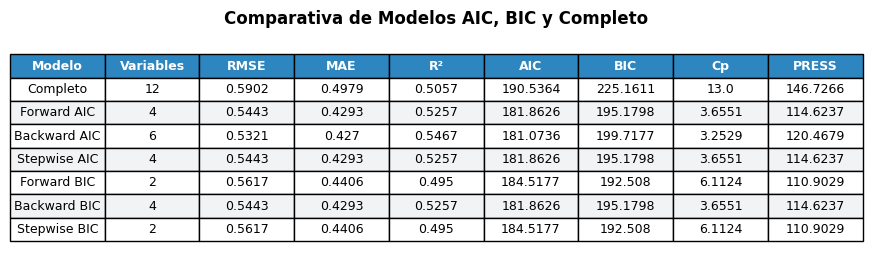

In [139]:
# Ajustar tamaño y estilo
fig, ax = plt.subplots(figsize=(10, 3))  # cambia (ancho, alto) según necesites
ax.axis('off')  # sin ejes

# Crear tabla en matplotlib
tabla = ax.table(
    cellText=tabla_modelos.round(4).values,  # redondea valores
    colLabels=tabla_modelos.columns,
    loc='center',
    cellLoc='center'
)

# Estilo general
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.1, 1.4)

# Estilo de encabezados
for (i, key) in enumerate(tabla_modelos.columns):
    cell = tabla[(0, i)]
    cell.set_facecolor("#2E86C1")  # azul encabezado
    cell.set_text_props(color='white', weight='bold')

# Fondo alternado para filas
for i in range(1, len(tabla_modelos)+1):
    for j in range(len(tabla_modelos.columns)):
        color = "#F2F3F4" if i % 2 == 0 else "white"
        tabla[(i, j)].set_facecolor(color)

# Título
plt.title("Comparativa de Modelos AIC, BIC y Completo", fontsize=12, fontweight='bold')

# Guardar como imagen PNG
plt.savefig("comparativa_modelos_tabla.png", bbox_inches='tight', dpi=300)

plt.show()


In [ ]:
#analizando distintos modelos el que mas confianza da fue el de backward AIC, debido a que si bien tiene un PRESS un poco mas elevado, se compensa con otras cosas como los niveles de r2 y de Cp, no estando ni sub ni sobreajustado, para evidenciar esto se hizo un grafico
#Para revisar y comparar, se graficaron los 2 mejores modelos que se obtuvieron, tanto el BACKWARD AIC, que es el mejor, y el STEPWISE AIC, el cual se postula como el segundo mejor

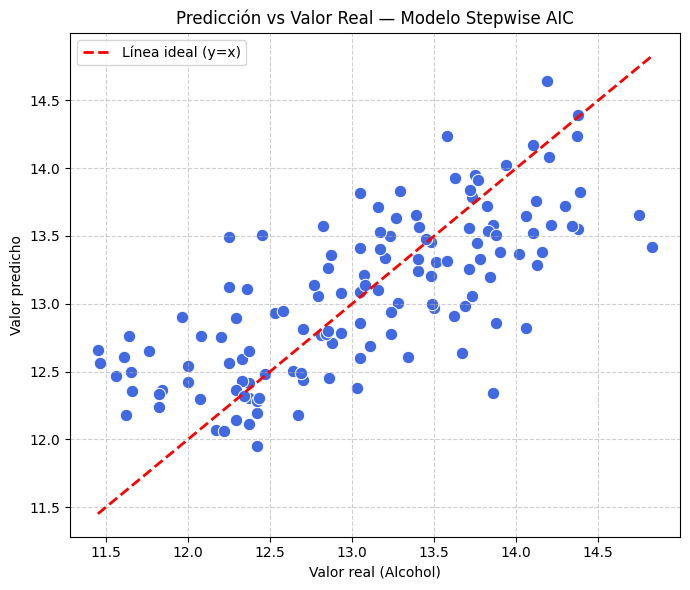

In [140]:
#GRAFICO DEL MODELO DEL STEPWISE APLICADO A TODAS LAS OBSERVACIONES

y_pred_all = model_stepwise_final.predict(sm.add_constant(X_sm[["Prolina",
    "Intensidad_color",
    "Acido_malico",
    "Magnesio"]]))

# Gráfico con todos los datos
plt.figure(figsize=(7,6))
sns.scatterplot(x=y, y=y_pred_all, color="royalblue", edgecolor="white", s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Línea ideal (y=x)")
plt.title("Predicción vs Valor Real — Modelo Stepwise AIC")
plt.xlabel("Valor real (Alcohol)")
plt.ylabel("Valor predicho")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

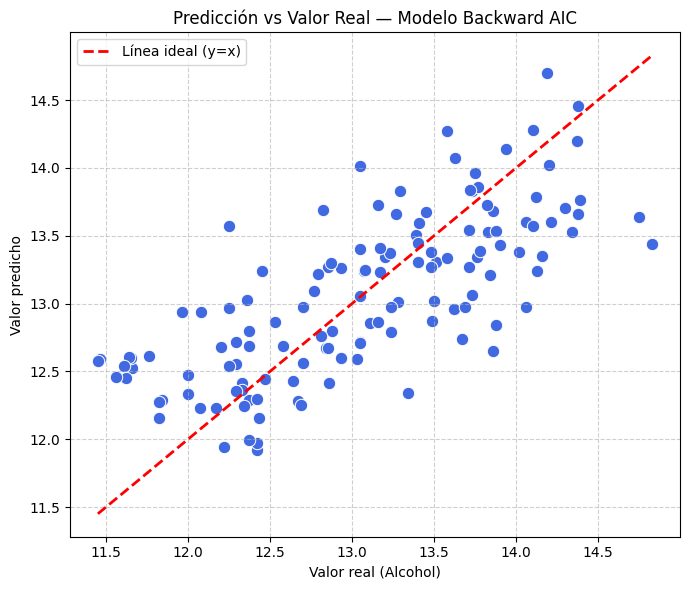

In [141]:
#GRAFICO DEL MODELO FINAL, EL BACKWARD AIC APLICADO A TODAS LAS OBSERVACIONES
y_pred_all = model_backward_final.predict(sm.add_constant(X_sm[["Prolina",
    "Intensidad_color",
    "Acido_malico",
    "Magnesio",
    "Tono_color",
    "Fenoles_no_flavonoides"]]))

# Gráfico con todos los datos
plt.figure(figsize=(7,6))
sns.scatterplot(x=y, y=y_pred_all, color="royalblue", edgecolor="white", s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Línea ideal (y=x)")
plt.title("Predicción vs Valor Real — Modelo Backward AIC")
plt.xlabel("Valor real (Alcohol)")
plt.ylabel("Valor predicho")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
#DESPUES PARA MEJOR INFORMACION SE HICIERON MAS GRAFICOS

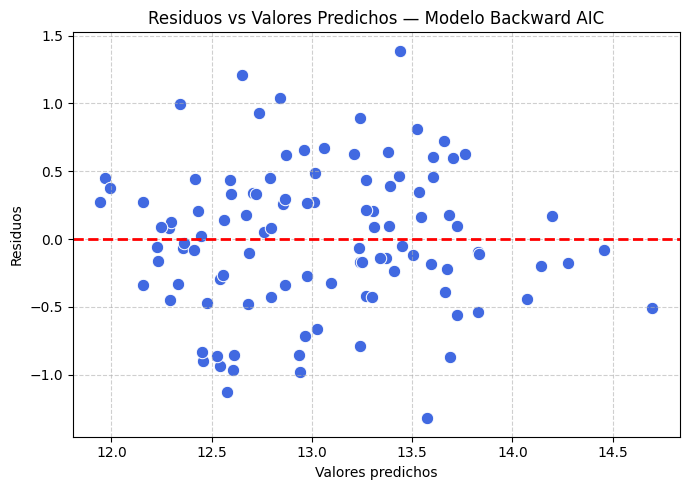

In [142]:
# GRAFICO DE RESIDUOS
residuos = y_train - model_backward_final.fittedvalues
y_pred = model_backward_final.fittedvalues

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred, y=residuos, color="royalblue", edgecolor="white", s=80)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Predichos — Modelo Backward AIC")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

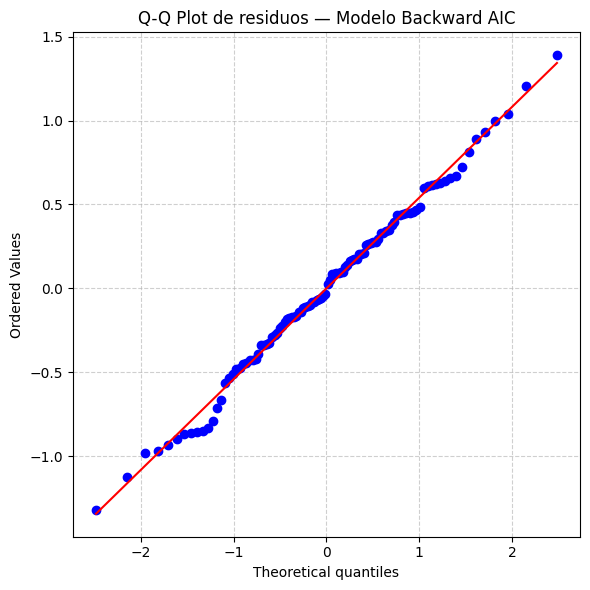

In [143]:
#GRAFICO Q-Q
plt.figure(figsize=(6,6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot de residuos — Modelo Backward AIC")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#Ahora ya con el modelo idea, el backward, podemos meter el csv del test para empezar a predecir los datos, para eso con el nuevo csv sin alcohol y menos id tenemos que organizarlo como al inicio en columnas tal cual el inicio

In [144]:
#Leemos el archivo CSV nuevo (debe estar en la misma carpeta que el .py o notebook)

#Muy importante, MUY IMPORTANTE, lo de las locaciones ya que si no hacemos esto, nada va a servir (solo en el caso de hacerlo de forma local, ya que aqui se hace desde github)

url_test = "https://raw.githubusercontent.com/MMaxuss/Modelo-Vinos-UCM/refs/heads/main/wine_test.csv"


df_test = pd.read_csv(url_test)

# Separar si todas las variables están en una columna
if df_test.shape[1] == 1:
    df_test = df_test[df_test.columns[0]].str.split(",", expand=True)
    new_header = df_test.iloc[0]
    df_test = df_test[1:]
    df_test.columns = new_header

# Convertir a float cuando sea posible
for col in df_test.columns:
    try:
        df_test[col] = df_test[col].astype(float)
    except ValueError:
        pass

print("Test limpio:", df_test.shape)

HTTPError: HTTP Error 429: Too Many Requests

In [ ]:
#Ahora con el csv nuevo listo, usamos el modelo elegido de variables (backward aic) para realizar la prediccion de datos

In [ ]:
# Variables usadas en el modelo Backward AIC

selected_vars_backward = [
    "Prolina",
    "Intensidad_color",
    "Acido_malico",
    "Magnesio",
    "Tono_color",
    "Fenoles_no_flavonoides"
]

# Verificar si todas las columnas están en el test
missing = [v for v in selected_vars_backward if v not in df_test.columns]
if missing:
    raise KeyError(f"Faltan columnas en wine_test.csv necesarias para el modelo: {missing}")

# Preparar datos para predicción

X_test_selected = df_test[selected_vars_backward].copy()
X_test_selected = sm.add_constant(X_test_selected, has_constant="add")

# Predicciones
df_test["Prediccion_Alcohol"] = model_backward_final.predict(X_test_selected)

df_output = pd.DataFrame({
    "id": df_test["id"],
    "y_hat": df_test["Prediccion_Alcohol"].round(2)
})

df_output.to_csv("predicciones_test.csv", index=False, sep=";")
print("Predicciones del test exportadas correctamente")